In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.b import Model_b
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [94]:
a = Model_b()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

[[[ 1.          7.60484406  9.38533539 10.95305415 12.11571785
   13.0239645  14.0306522 ]]]


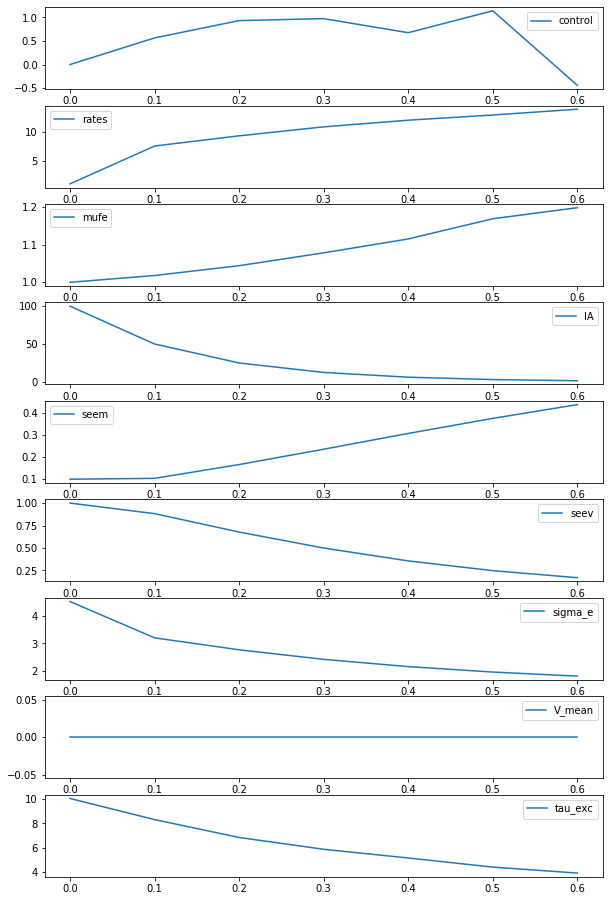

In [95]:
dur = 0.6

a.params.duration = dur
a.params.ext_exc_current = 2.

target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,5] += 1.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.state["rates_exc"][0,:]

fig, axes = plt.subplots(9, figsize=(10, 16))
axes[0].plot(a.t, control1[0,0,:], label="control")
axes[1].plot(a.t, a.state["rates_exc"][0,:], label="rates")
axes[2].plot(a.t, a.state["mufe"][0,:], label="mufe")
axes[3].plot(a.t, a.state["IA"][0,:], label="IA")
axes[4].plot(a.t, a.state["seem"][0,:], label="seem")
axes[5].plot(a.t, a.state["seev"][0,:], label="seev")
axes[6].plot(a.t, a.state["sigmae_f"][0,:], label="sigma_e")
axes[7].plot(a.t, a.state["Vmean_exc"][0,:], label="V_mean")
axes[8].plot(a.t, a.state["tau_exc"][0,:], label="tau_exc")
for i in range(9):
    axes[i].legend()

print(target)

In [97]:
max_cntrl = 10. * 5.
start_step = 10.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init, a.params.seem_init, a.params.seev_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 1.

max_it = 80

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  0.07839876298704278
RUN  1 , total integrated cost =  0.0654122717736622
RUN  2 , total integrated cost =  0.06541142461873757
RUN  3 , total integrated cost =  0.06541142347035009
RUN  4 , total integrated cost =  0.06541142346949225
RUN  5 , total integrated cost =  0.06541142346949191
RUN  6 , total integrated cost =  0.06541142346949168
RUN  7 , total integrated cost =  0.06541142346949161
RUN  8 , total integrated cost =  0.06541142346949086
RUN  9 , total integrated cost =  0.06541142346949066
RUN  10 , total integrated cost =  0.06541142346949017
RUN  11 , total integrated cost =  0.06541142346948997
RUN  12 , total integrated cost =  0.06541142346948989
RUN  13 , total integrated cost =  0.06541142346948978
RUN  14 , total integrated cost =  0.06541142346948922
RUN  15 , total integrated cost =  0.0654114234694892
RUN  16 , total integrated cost =  0.06541142346948911
RUN  17 , total integrated cost =  0.06541142346948883
RUN  1

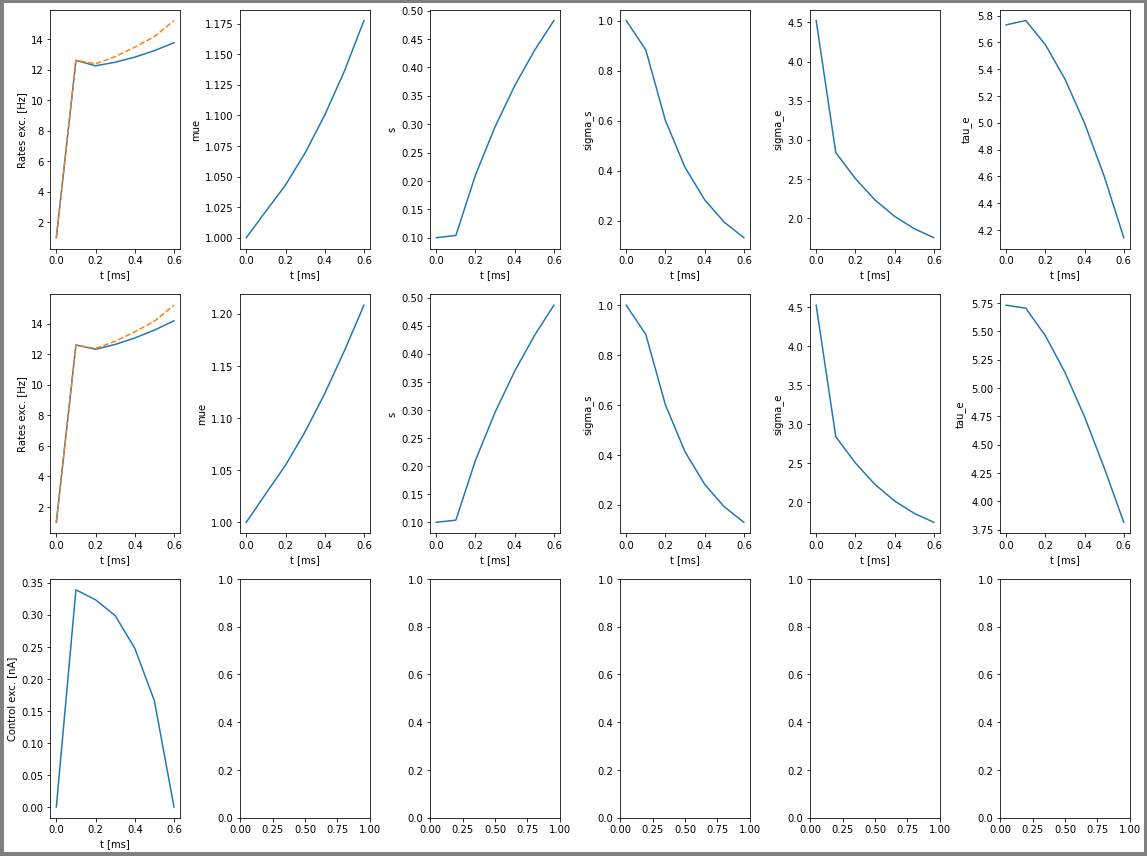

In [257]:
"""
RUN  39 , total integrated cost =  0.11946866518622404
Control only changes marginally.
Improved over  39  iterations by  32.1987963806712  percent.
final gradient =  [[[ 0.00000000e+00 -7.54107221e-10 -6.89369561e-10 -5.98488592e-10
   -4.56948424e-10 -2.54115340e-10  0.00000000e+00]]]
"""
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [86]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 30

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  1.0700223513219629
RUN  1 , total integrated cost:  0.4468907353959345
RUN  2 , total integrated cost:  0.30667752486564576
RUN  3 , total integrated cost:  0.2954172220339836
RUN  4 , total integrated cost:  0.2942715144548896
change helped, counter =  1
RUN  5 , total integrated cost:  0.29398092559342986
RUN  6 , total integrated cost:  0.29393021067134356
change helped, counter =  1
change helped, counter =  2
RUN  7 , total integrated cost:  0.29392433389350564
change helped, counter =  2
RUN  8 , total integrated cost:  0.2939240366477139
change helped, counter =  3
change helped, counter =  1
change helped, counter =  1
change helped, counter =  2
RUN  9 , total integrated cost:  0.29392390483969805
change helped, counter =  1
change helped, counter =  4
change helped, counter =  2
RUN  10 , total integrated cost:  0.29392389778555505
change helped, counter =  2
RUN  11 , total integrated cost:  0.29392389778555417
change helped, c

[[[0.         0.3391065  0.32351423 0.29888377 0.24779158 0.16599314
   0.        ]]]


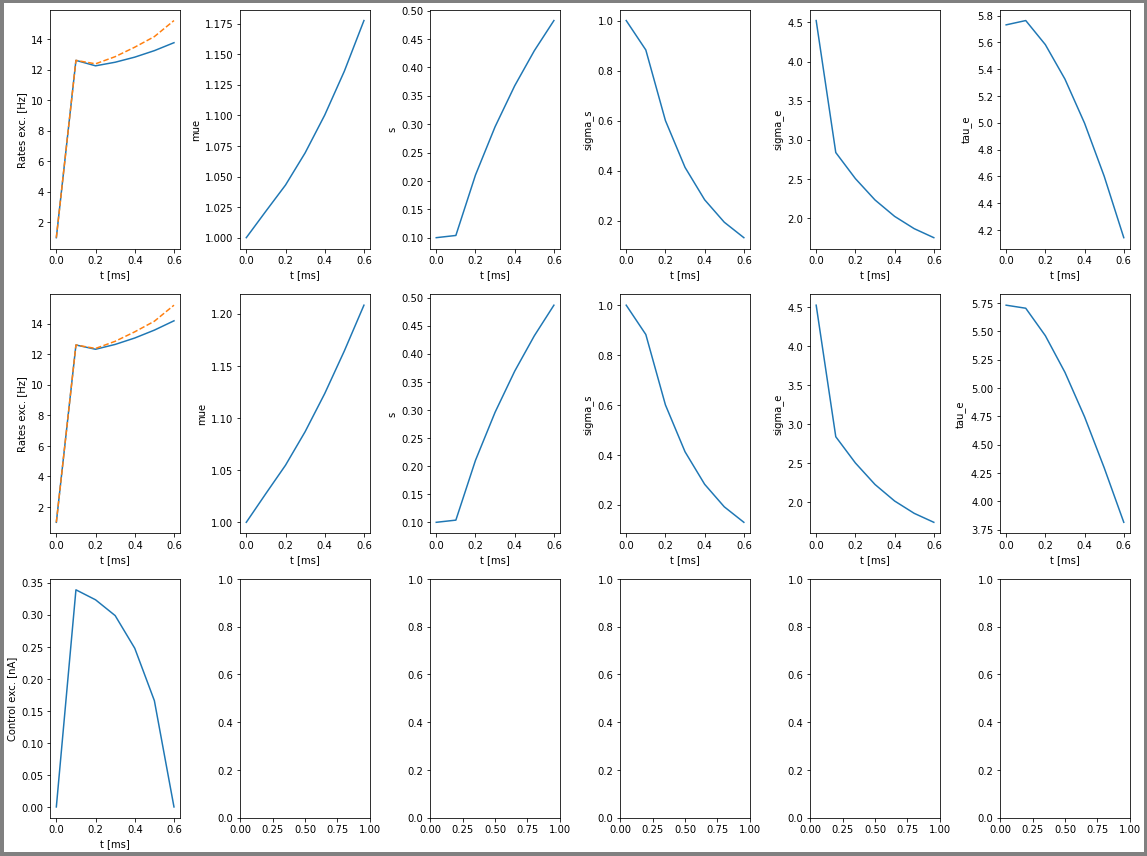

In [259]:
# 0.2939238963346936
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

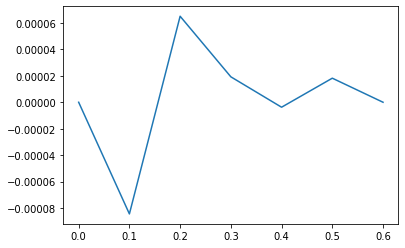

In [87]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

(350, 64, 2)


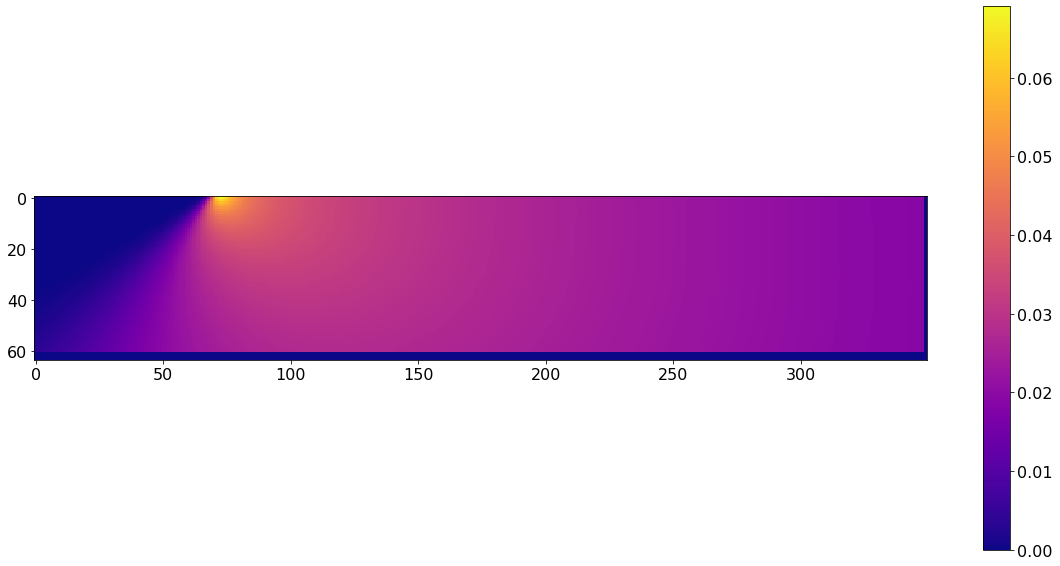

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


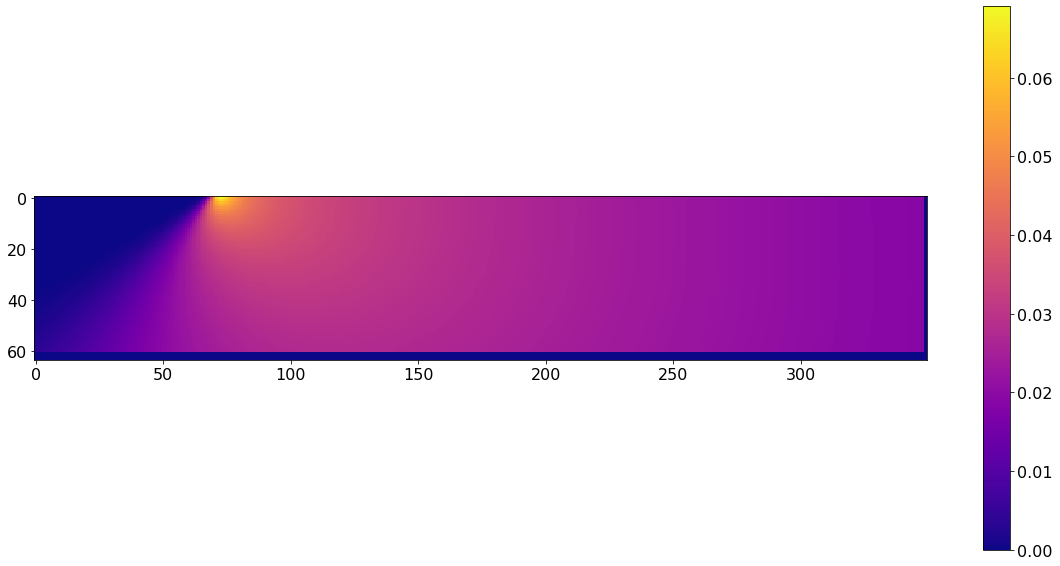

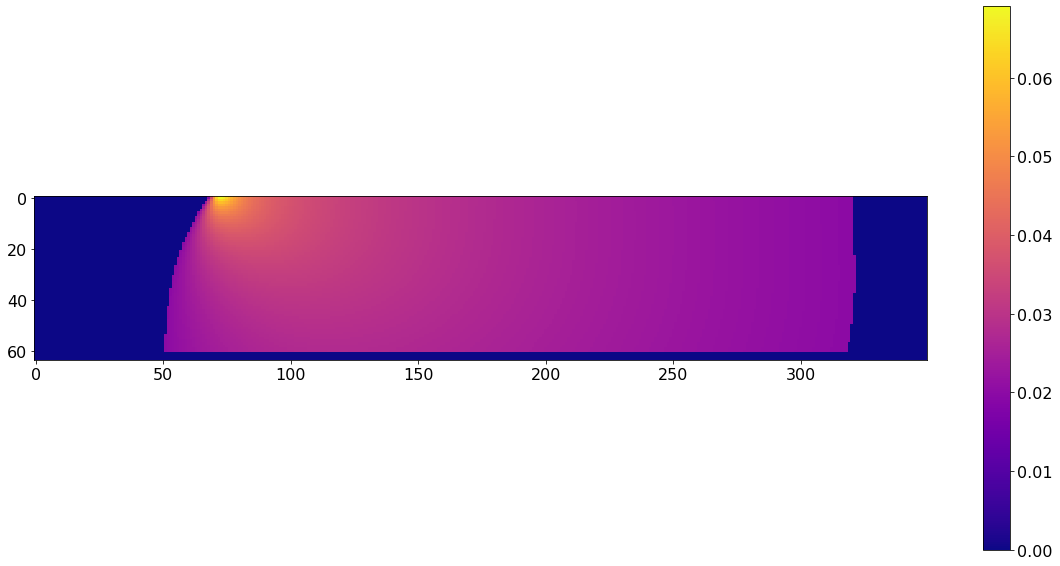

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()